In [1]:
from datetime import datetime, time
import pandas as pd
import numpy as np
from itertools import product
from Strategies.Modular_strategy.calibration import ModularStrategyCalibration
from Strategies.Modular_strategy.backtest_class import BacktestModular
from Strategies.Modular_strategy.strategy_class import ModularStrategy
from Strategies.Modular_strategy.strategy_class_new import ModularStrategy as NewStrategy
from Strategies.Sparse_momentum.ob_attributes import OB_attributes, TR_attributes


import pickle
from Strategies.Modular_strategy.features import *
from Strategies.Sparse_momentum.ob_attributes import OB_attributes
from OrderBook.OrderBook import OrderBookSnaps
from SynthSpread.spreadviewer_class import SpreadSingle
from Database.TPData import TPData, TPDataDa
from Utilities.excel_loaders import conn_out_xload
from Utilities.dfutils import date_filter
from Utilities.Storage import get_curr_storage_path

In [2]:
from Database.DB_reader import Database
db = Database('timescaledb')

In [3]:
start_date = '2025-04-01'
end_date = '2025-04-10'

### Get index for EEX instruments

In [ ]:
# 1. Read data from source DB
conn = Database('timescaledb')

query=f"""select distinct datetime, nanotime, tradeid from  public.trades 
          where datetime>='{start_date}' and datetime<='{end_date}' 
          and EXTRACT(HOUR FROM datetime) BETWEEN 8 AND 18
          and instid in ('10641710', '10001075', '10100480', '10012528', '10002806')
          and aggressorbroker_id_ut = 14
          order by datetime asc, nanotime asc""" # where rownum <= 100"""
df_index = conn.execute(query)


print(f"✅ Loaded {len(df_index)} rows from source database.")

Connected to the database timescaledb


In [ ]:
from Database.Timescale.utils import get_trades_data

In [ ]:
_INSTRUMENT = 'dem2'

In [ ]:
trades = get_trades_data(_INSTRUMENT, start_date, end_date)

Connected to the database timescaledb
Disconnected from the database timescaledb
Connected to the database timescaledb
Disconnected from the database timescaledb
Connected to the database timescaledb
Disconnected from the database timescaledb
Connected to the database timescaledb
Disconnected from the database timescaledb
Connected to the database timescaledb
Disconnected from the database timescaledb
Connected to the database timescaledb
Disconnected from the database timescaledb
Connected to the database timescaledb
Disconnected from the database timescaledb
Connected to the database timescaledb
Disconnected from the database timescaledb


In [43]:
pred_ids = [
    'obook_a_price_' + _INSTRUMENT,
    'obook_b_price_' + _INSTRUMENT,
    'obook_b_price_sparsity_' + _INSTRUMENT,
    'obook_a_price_sparsity_' + _INSTRUMENT,
    'obook_ba_volrat_00_' + _INSTRUMENT,
    'obook_ba_volrat_30_' + _INSTRUMENT,
    'obook_ba_volrat_50_' + _INSTRUMENT,
    'obook_ba_volrat_90_' + _INSTRUMENT,
    f'll_aux_dem1_{_INSTRUMENT}_fair_price',
    f'll_aux_dem1_{_INSTRUMENT}_fair_ret',
    # 'll_aux_deq1_dey1_fair_price',
    # 'll_aux_deq1_dey1_fair_ret',
    # 'll_aux_dem2_dey1_fair_price',
    # 'll_aux_dem2_dey1_fair_ret',
    _INSTRUMENT + '_VI_mid_std_200',
    _INSTRUMENT + '_target_class_long_prob_400_VI_mid_std_200',
    _INSTRUMENT + '_target_class_short_prob_400_VI_mid_std_200',
    f'atr_{_INSTRUMENT}_candles_5min_lookback_21',
    f'atr_{_INSTRUMENT}_candles_10min_lookback_21',
    f'atr_1h_21_{_INSTRUMENT}'

]

In [110]:
query = f"""
    SELECT *
    FROM public.experimental_predictors
    WHERE main_contract like '{_INSTRUMENT}';
"""
data = db.execute_general_query(query)
pred_ids = data['pred_id'].values
print(pred_ids)

Connected to the database timescaledb
Disconnected from the database timescaledb
['atr_dem2_M_candles_5min_lookback_21' 'dem2_VI_mid_std_200'
 'atr_dem2_M_candles_15min_lookback_21'
 'atr_dem2_candles_5min_lookback_21' 'atr_dem2_candles_10min_lookback_21'
 'atr_dem2_M_candles_10min_lookback_21'
 'dem2_target_class_long_prob_400_VI_mid_std_200'
 'atr_dem2_M_candles_30min_lookback_21'
 'macd_dem2_M_candles_5min_params_12_26_9'
 'macd_dem2_M_candles_30min_params_12_26_9'
 'macd_dem2_M_candles_30min_params_8_21_5' 'll_aux_dem1_dem2_fair_price'
 'll_aux_dem1_dem2_fair_ret' 'll_aux_deq1_dem2_fair_price'
 'll_aux_deq1_dem2_fair_ret' 'll_aux_dey1_dem2_fair_price'
 'll_aux_dey1_dem2_fair_ret'
 'dem2_target_class_short_prob_400_VI_mid_std_200'
 'atr_dem2_M_candles_1h_lookback_21'
 'macd_dem2_M_candles_5min_params_8_21_5'
 'macd_dem2_M_candles_10min_params_12_26_9'
 'macd_dem2_M_candles_10min_params_8_21_5'
 'macd_dem2_M_candles_15min_params_12_26_9'
 'macd_dem2_M_candles_15min_params_8_21_5' 'at

In [112]:
for pred_id in pred_ids:
    query = f"""
        SELECT *
        FROM public.experimental_dataset_entries
        WHERE pred_id like '{pred_id}'
        AND datetime>='{start_date}' and datetime<='{end_date}' 
    """
    data = db.execute_general_query(query)
    if not data.empty:
        df_aux = data[['tradeid', 'datetime', 'nanotime']].copy()
        df_aux[pred_id] = data['pred_value'].astype(float)
        df_index = pd.merge(df_index, df_aux[['tradeid', pred_id]], on='tradeid', how='inner')

# Optionally, fill missing values if needed:
# result_df = result_df.fillna(np.nan)

Connected to the database timescaledb
Disconnected from the database timescaledb
Connected to the database timescaledb
Disconnected from the database timescaledb
Connected to the database timescaledb
Disconnected from the database timescaledb
Connected to the database timescaledb
Disconnected from the database timescaledb
Connected to the database timescaledb
Disconnected from the database timescaledb
Connected to the database timescaledb
Disconnected from the database timescaledb
Connected to the database timescaledb
Disconnected from the database timescaledb
Connected to the database timescaledb
Disconnected from the database timescaledb
Connected to the database timescaledb
Disconnected from the database timescaledb
Connected to the database timescaledb
Disconnected from the database timescaledb
Connected to the database timescaledb
Disconnected from the database timescaledb
Connected to the database timescaledb
Disconnected from the database timescaledb
Connected to the database ti

In [117]:
df_index

,tradeid,datetime,nanotime,obook_a_price_dem2_x,obook_b_price_dem2_x,obook_b_price_sparsity_dem2_x,obook_a_price_sparsity_dem2_x,obook_ba_volrat_00_dem2_x,obook_ba_volrat_30_dem2_x,obook_ba_volrat_50_dem2_x,...,dem2_target_class_short_prob_400_VI_mid_std_200_y,atr_dem2_M_candles_1h_lookback_21,obook_ba_volrat_00_dem2_y,obook_ba_volrat_30_dem2_y,obook_ba_volrat_50_dem2_y,obook_ba_volrat_90_dem2_y,obook_b_price_sparsity_dem2_y,obook_a_price_sparsity_dem2_y,obook_b_price_dem2_y,obook_a_price_dem2_y
0,Eurex T7/G3BM052025-20250401/4/1,2025-04-01 08:00:48,502375458.0,70.11,70.00,0.07,0.13,0.428571,0.243243,0.219512,...,NaN,0.621905,0.428571,0.243243,0.219512,0.219512,0.07,0.13,70.00,70.11
1,Eurex T7/G3BM052025-20250401/4/1,2025-04-01 08:00:48,502375458.0,70.11,70.00,0.07,0.13,0.428571,0.243243,0.219512,...,NaN,0.621905,0.428571,0.243243,0.219512,0.219512,0.07,0.13,70.00,70.11
2,Eurex T7/DEBM052025-20250401/5/1,2025-04-01 08:10:54,46700229.0,70.10,70.00,0.07,0.04,0.666667,0.210526,0.136364,...,NaN,0.621905,0.666667,0.210526,0.136364,0.136364,0.07,0.04,70.00,70.10
3,Eurex T7/DEBM052025-20250401/5/1,2025-04-01 08:10:54,46700229.0,70.10,70.00,0.07,0.04,0.666667,0.210526,0.136364,...,NaN,0.621905,0.666667,0.210526,0.136364,0.136364,0.07,0.04,70.00,70.10
4,Eurex T7/G3BM052025-20250401/8/3,2025-04-01 08:19:40,48551772.0,70.11,70.00,0.07,0.14,0.666667,0.483871,0.250000,...,NaN,0.621905,0.666667,0.483871,0.250000,0.250000,0.07,0.14,70.00,70.11
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
72194,Eurex T7/G3BM052025-20250409/6252/1,2025-04-09 12:44:08,437778810.0,71.70,71.54,0.03,0.05,-0.200000,0.000000,0.017544,...,0.274314,0.780476,-0.200000,0.000000,0.017544,0.017544,0.03,0.05,71.54,71.70
72195,Eurex T7/DEBQ072025-20250409/6253/1,2025-04-09 12:44:10,167375529.0,71.70,71.54,0.03,0.05,-0.200000,0.020408,0.035714,...,0.279302,0.780476,-0.200000,0.020408,0.035714,0.035714,0.03,0.05,71.54,71.70
72196,Eurex T7/DEBM052025-20250409/6254/1,2025-04-09 12:44:10,167685542.0,71.70,71.54,0.03,0.05,0.333333,0.063830,0.074074,...,0.281796,0.780476,0.333333,0.063830,0.074074,0.074074,0.03,0.05,71.54,71.70
72197,Eurex T7/DEBQ072025-20250409/6255/1,2025-04-09 12:44:10,167721624.0,71.70,71.54,0.03,0.05,0.333333,0.063830,0.074074,...,0.284289,0.780476,0.333333,0.063830,0.074074,0.074074,0.03,0.05,71.54,71.70


In [39]:
df_index.set_index('tradeid', inplace=True)
df_index['trd_price'] = trades.set_index('tradeid').reindex(df_index.index)['price']

In [40]:
df_data = df_index.copy()

In [53]:
df_data[df_data['trd_price'] > 0]

,datetime,nanotime,obook_a_price_dem2,obook_b_price_dem2,obook_b_price_sparsity_dem2,obook_a_price_sparsity_dem2,obook_ba_volrat_00_dem2,obook_ba_volrat_30_dem2,obook_ba_volrat_50_dem2,obook_ba_volrat_90_dem2,...,ll_aux_dem1_dem2_fair_ret,dem2_VI_mid_std_200,dem2_target_class_long_prob_400_VI_mid_std_200,dem2_target_class_short_prob_400_VI_mid_std_200,atr_dem2_candles_5min_lookback_21,atr_dem2_candles_10min_lookback_21,atr_1h_21_dem2,trd_price,trd_side,trd_gap
tradeid,,,,,,,,,,,,,,,,,,,,,
Eurex T7/DEBM062025-20250401/338/1,2025-04-01 09:09:23,160543735.0,70.19,69.82,0.11,0.10,-0.200000,-0.111111,0.200000,0.288889,...,NaN,0.044365,0.000000,0.000000,0.000000,0.073333,NaN,72.41,0.0,2.59
Eurex T7/DEBM062025-20250401/338/1,2025-04-01 09:09:23,160543735.0,70.19,69.82,0.11,0.10,-0.200000,-0.111111,0.200000,0.288889,...,NaN,0.044365,0.000000,0.000000,0.000000,0.073333,NaN,72.41,0.0,2.59
Eurex T7/DEBM062025-20250401/375/1,2025-04-01 09:12:13,92310943.0,70.18,69.89,0.17,0.11,-0.200000,-0.111111,0.200000,0.288889,...,NaN,0.040593,0.000000,0.000000,0.019524,0.077143,NaN,72.68,0.0,2.79
Eurex T7/DEBM062025-20250401/375/1,2025-04-01 09:12:13,92310943.0,70.18,69.89,0.17,0.11,-0.200000,-0.111111,0.200000,0.288889,...,NaN,0.040593,0.000000,0.000000,0.019524,0.077143,NaN,72.68,0.0,2.79
Eurex T7/DEBM062025-20250401/384/1,2025-04-01 09:12:39,270428126.0,70.13,69.82,0.14,0.14,-0.500000,-0.111111,0.314286,0.400000,...,NaN,0.040790,0.000000,0.000000,0.019524,0.077143,NaN,72.58,0.0,2.76
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Eurex T7/DEBM062025-20250409/6081/1,2025-04-09 12:41:48,114641867.0,71.45,71.36,0.06,0.07,-0.333333,0.025641,0.136364,0.137255,...,NaN,0.019522,0.174564,0.000000,0.137619,0.230952,0.780476,63.50,1.0,-7.95
Eurex T7/DEBM062025-20250409/6101/1,2025-04-09 12:42:53,811977484.0,71.42,71.35,0.09,0.10,0.333333,0.393939,0.315789,0.288889,...,NaN,0.019265,0.174564,0.000000,0.137619,0.230952,0.780476,63.55,1.0,-7.87
Eurex T7/DEBM062025-20250409/6105/2,2025-04-09 12:43:20,554136614.0,71.42,71.35,0.09,0.08,0.600000,0.393939,0.368421,0.333333,...,NaN,0.019189,0.174564,0.000000,0.137619,0.230952,0.780476,63.59,1.0,-7.83


In [44]:
for col in pred_ids:
    df_data[col] = df_data[col].astype(float)

In [46]:
is_closer_to_bid = abs(df_data['obook_b_price_dem2'] - df_data['trd_price']) < abs(df_data['obook_a_price_dem2'] - df_data['trd_price'])

In [47]:
df_data['trd_side'] = np.where(df_data['trd_price'] > 0,
                               np.where(is_closer_to_bid, 1.0, 0.0),
                               np.nan)  # Or whatever default you want for 

### Trd gap

In [ ]:
cond_outside_spread = (df_data['trd_price'] > df_data['obook_a_price_dem2']) | \
                      (df_data['trd_price'] < df_data['obook_b_price_dem2'])

# Condition 2: Is trd_side > 0.5? (relevant only if cond_outside_spread is True)
cond_trd_side_gt_half = df_data['trd_side'] > 0.5

# Define the choices for np.select
# Each condition in 'conditions' corresponds to a choice in 'choices'
conditions = [
    cond_outside_spread & cond_trd_side_gt_half,   # Outside spread AND trd_side > 0.5
    cond_outside_spread & ~cond_trd_side_gt_half,  # Outside spread AND trd_side <= 0.5 (or NaN)
    # The default will cover the case where cond_outside_spread is False
]

choices = [
    (df_data['trd_price'] - df_data['obook_a_price_dem2']).round(2),  # Gap to ask price
    (df_data['trd_price'] - df_data['obook_b_price_dem2']).round(2)   # Gap to bid price
]

# Use np.select
# The 'default' argument is used when none of the conditions in 'conditions' are met.
# This corresponds to the 'else: return 0.0' in your original function.
df_data['trd_gap'] = np.select(conditions, choices, default=0.0)

### Fair price gap

In [101]:
# Calculate distances to both bid and ask
ask_distance = (df_data[f'll_aux_dem1_{_INSTRUMENT}_fair_price'] - df_data['obook_a_price_dem2']).round(2)
bid_distance = (df_data[f'll_aux_dem1_{_INSTRUMENT}_fair_price'] - df_data['obook_b_price_dem2']).round(2)

# Take the distance with smaller absolute value (closest order)
df_data['fair_price_gap'] = np.where(
    abs(ask_distance) <= abs(bid_distance),
    ask_distance,  # Distance to ask
    bid_distance   # Distance to bid
)

### Rolling features

In [194]:
cols = ['obook_a_price_sparsity_dem2',
        'obook_b_price_sparsity_dem2']
windows = [50, 100, 200]
for c in cols:
    for w in windows:
        df_data[str(c) + '_rolling_' + str(w)] = df_data[c] - df_data[c].rolling(w).mean()

In [224]:
df_data.filter(like='sparsity').columns

Index(['obook_b_price_sparsity_dem2', 'obook_a_price_sparsity_dem2',
       'obook_a_price_sparsity_dem2_rolling_50',
       'obook_a_price_sparsity_dem2_rolling_100',
       'obook_a_price_sparsity_dem2_rolling_200',
       'obook_b_price_sparsity_dem2_rolling_50',
       'obook_b_price_sparsity_dem2_rolling_100',
       'obook_b_price_sparsity_dem2_rolling_200'],
      dtype='object')

<Axes: xlabel='tradeid'>

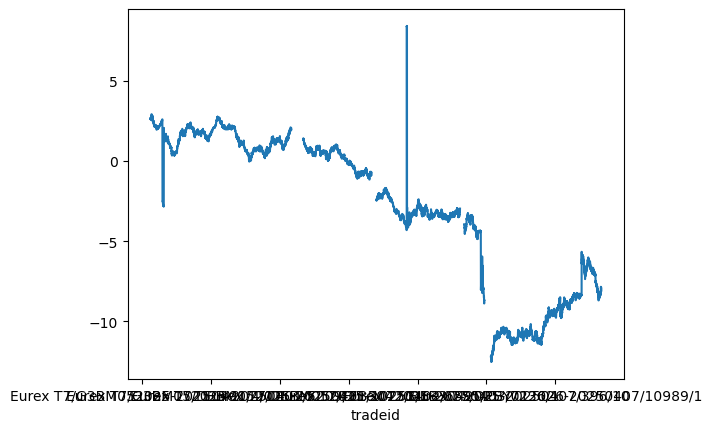

In [103]:
df_data['fair_price_gap'].plot()

## Feature columns

In [118]:
feature_cols=[
    'obook_b_price_sparsity_dem2', 
    'obook_a_price_sparsity_dem2', 
    'obook_ba_volrat_00_dem2', 
    'obook_ba_volrat_30_dem2', 
    'obook_ba_volrat_50_dem2', 
    'obook_ba_volrat_90_dem2', 
    'fair_price_gap',
    'll_aux_dem1_dem2_fair_ret',
    'dem2_VI_mid_std_200',
    'atr_dem2_candles_5min_lookback_21',
    'atr_dem2_candles_10min_lookback_21', 
    'atr_1h_21_dem2', 
    'trd_gap']

In [83]:
class_thold = 0.5

In [ ]:
df_data[df_data['dem2_target_class_long_prob_400_VI_mid_std_200'] > 0.6]

,datetime,nanotime,obook_a_price_dem2,obook_b_price_dem2,obook_b_price_sparsity_dem2,obook_a_price_sparsity_dem2,obook_ba_volrat_00_dem2,obook_ba_volrat_30_dem2,obook_ba_volrat_50_dem2,obook_ba_volrat_90_dem2,...,ll_aux_dem1_dem2_fair_ret,dem2_VI_mid_std_200,dem2_target_class_long_prob_400_VI_mid_std_200,dem2_target_class_short_prob_400_VI_mid_std_200,atr_dem2_candles_5min_lookback_21,atr_dem2_candles_10min_lookback_21,atr_1h_21_dem2,trd_price,trd_side,trd_gap
tradeid,,,,,,,,,,,,,,,,,,,,,
Eurex T7/G3BM052025-20250401/1796/1,2025-04-01 10:40:35,160379520.0,70.09,69.29,0.32,0.38,0.333333,0.666667,0.523810,0.400000,...,-1.815223,0.380360,0.735661,0.0,0.142857,0.132857,NaN,NaN,NaN,0.0
Eurex T7/G3BM052025-20250401/1796/1,2025-04-01 10:40:35,160379520.0,70.09,69.29,0.32,0.38,0.333333,0.666667,0.523810,0.400000,...,-1.815223,0.380360,0.735661,0.0,0.142857,0.132857,NaN,NaN,NaN,0.0
Eurex T7/G3BM052025-20250401/1797/1,2025-04-01 10:40:35,175108028.0,70.09,69.29,0.32,0.38,0.333333,0.666667,0.523810,0.400000,...,-1.815223,0.385834,0.738155,0.0,0.142857,0.132857,NaN,NaN,NaN,0.0
Eurex T7/G3BM052025-20250401/1797/1,2025-04-01 10:40:35,175108028.0,70.09,69.29,0.32,0.38,0.333333,0.666667,0.523810,0.400000,...,-1.815223,0.385834,0.738155,0.0,0.142857,0.132857,NaN,NaN,NaN,0.0
Eurex T7/G3BM052025-20250401/1798/1,2025-04-01 10:40:35,189779981.0,70.09,69.29,0.32,0.38,0.333333,0.666667,0.523810,0.400000,...,-1.815223,0.416954,0.740648,0.0,0.142857,0.132857,NaN,NaN,NaN,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Eurex T7/DWB3042025-20250409/3831/5,2025-04-09 11:11:01,183894344.0,71.64,71.54,0.05,0.07,-0.333333,-0.142857,-0.056604,-0.066667,...,NaN,0.046490,0.765586,0.0,0.158571,0.173333,0.783333,NaN,NaN,0.0
Eurex T7/DEBM052025-20250409/3832/1,2025-04-09 11:11:04,145506381.0,71.64,71.54,0.05,0.07,-0.333333,-0.142857,-0.056604,-0.066667,...,NaN,0.047171,0.765586,0.0,0.158571,0.173333,0.783333,NaN,NaN,0.0
Eurex T7/DEBM052025-20250409/3833/1,2025-04-09 11:11:04,146895902.0,71.64,71.55,0.04,0.07,-0.333333,-0.200000,-0.102041,-0.107143,...,NaN,0.047966,0.765586,0.0,0.158571,0.173333,0.783333,NaN,NaN,0.0


## Multiclass label

In [84]:
def multiclass_label(row):
    if row['dem2_target_class_long_prob_400_VI_mid_std_200'] >= class_thold:
        return 2
    elif row['dem2_target_class_short_prob_400_VI_mid_std_200'] >= class_thold:
        return 0
    else:
        return 1

# Apply the function to create the new column
df_data['multiclass_label'] = df_data.apply(multiclass_label, axis=1)


In [271]:
loss_mx = np.array([
    [0, 1, 3],
    [1, 0, 1],
    [3, 1, 0]
])

In [85]:
df_data['multiclass_label'].value_counts()/df_data.shape[0]

multiclass_label
1    0.874777
2    0.072369
0    0.052854
Name: count, dtype: float64

## Filtering imbalance

In [245]:
import pandas as pd
import numpy as np
from itertools import combinations

class DataConditioningFramework:
    def __init__(self, df_data, target_col='multiclass_label', feature_cols=None, min_sample_size=100):
        self.df_data = df_data
        self.target_col = target_col
        self.min_sample_size = min_sample_size
        
        # Use provided feature columns or auto-detect numeric ones
        if feature_cols is not None:
            self.feature_cols = feature_cols
        else:
            self.feature_cols = df_data.select_dtypes(include=np.number).columns.tolist()
            # Remove target column if it's in the list
            if target_col in self.feature_cols:
                self.feature_cols.remove(target_col)
        
        # Store original distribution for comparison
        self.original_dist = df_data[target_col].value_counts(normalize=True).sort_index()
        self.original_size = len(df_data)
        
    def _calculate_balance_score(self, class_dist, sample_size):
        """Calculate comprehensive balance score"""
        minority_ratio = min(class_dist.values)
        directional_ratio = class_dist.get(0, 0) + class_dist.get(2, 0)  # Short + Long
        size_retention = sample_size / self.original_size
        
        # Weighted score: balance * directional_strength * size_retention
        # balance_score = (minority_ratio * 0.4 + 
        #                 directional_ratio * 0.4 + 
        #                 size_retention * 0.2) * sample_size
        
        return minority_ratio
    
    def _apply_conditions(self, conditions_list):
        """Apply a list of conditions and return filtered dataframe"""
        mask = pd.Series(True, index=self.df_data.index)
        
        for feature, condition, threshold in conditions_list:
            if condition == '>=':
                mask &= (self.df_data[feature] >= threshold)
            elif condition == '<':
                mask &= (self.df_data[feature] < threshold)
            elif condition == '>':
                mask &= (self.df_data[feature] > threshold)
            elif condition == '<=':
                mask &= (self.df_data[feature] <= threshold)
            elif condition == 'abs>':
                mask &= (abs(self.df_data[feature]) > threshold)
            elif condition == 'abs>=':
                mask &= (abs(self.df_data[feature]) >= threshold)
            elif condition == 'abs<':
                mask &= (abs(self.df_data[feature]) < threshold)
            elif condition == 'abs<=':
                mask &= (abs(self.df_data[feature]) <= threshold)
        
        return self.df_data[mask]
    
    def _test_single_conditions(self):
        """Test all single feature conditions including abs< """
        results = []
        
        for feature in self.feature_cols:
            for percentile in [10, 20, 30, 40, 50, 60, 70, 80, 90]:
                threshold = self.df_data[feature].quantile(percentile/100)
                abs_threshold = abs(self.df_data[feature]).quantile(percentile/100)
                
                # Test all condition types including abs<
                conditions = [
                    ('>=', self.df_data[feature] >= threshold, threshold),
                    ('<', self.df_data[feature] < threshold, threshold),
                    ('abs>', abs(self.df_data[feature]) > abs_threshold, abs_threshold),
                    ('abs<', abs(self.df_data[feature]) < abs_threshold, abs_threshold)
                ]
                
                for condition_name, mask, thresh in conditions:
                    filtered_data = self.df_data[mask]
                    
                    if len(filtered_data) >= self.min_sample_size:
                        class_dist = filtered_data[self.target_col].value_counts(normalize=True)
                        balance_score = self._calculate_balance_score(class_dist, len(filtered_data))
                        
                        results.append({
                            'strategy': 'single_condition',
                            'feature': feature,
                            'condition': condition_name,
                            'threshold': thresh,
                            'sample_size': len(filtered_data),
                            'size_retention': len(filtered_data) / self.original_size,
                            'class_0_ratio': class_dist.get(0, 0),
                            'class_1_ratio': class_dist.get(1, 0),
                            'class_2_ratio': class_dist.get(2, 0),
                            'balance_score': balance_score,
                            'conditions_used': [(feature, condition_name, thresh)]
                        })
        
        return results
    
    def _test_threshold_optimization(self):
        """Test different probability thresholds for creating labels (optional)"""
        results = []
        
        long_prob_col = 'dem2_target_class_long_prob_400_VI_mid_std_200'
        short_prob_col = 'dem2_target_class_short_prob_400_VI_mid_std_200'
        
        # Only run if these columns exist
        if long_prob_col in self.df_data.columns and short_prob_col in self.df_data.columns:
            for long_thresh in np.arange(0.3, 0.8, 0.1):  # Reduced range for speed
                for short_thresh in np.arange(0.3, 0.8, 0.1):
                    # Create new labels with these thresholds
                    new_labels = np.where(
                        self.df_data[long_prob_col] >= long_thresh, 2,
                        np.where(self.df_data[short_prob_col] >= short_thresh, 0, 1)
                    )
                    
                    class_dist = pd.Series(new_labels).value_counts(normalize=True)
                    
                    # Only consider if we have meaningful directional classes
                    if len(class_dist) == 3 and class_dist.get(0, 0) > 0.05 and class_dist.get(2, 0) > 0.05:
                        balance_score = self._calculate_balance_score(class_dist, len(self.df_data))
                        
                        results.append({
                            'strategy': 'threshold_optimization',
                            'feature': 'probability_thresholds',
                            'condition': f'long>={long_thresh:.2f}_short>={short_thresh:.2f}',
                            'threshold': f'{long_thresh:.2f},{short_thresh:.2f}',
                            'sample_size': len(self.df_data),
                            'size_retention': 1.0,
                            'class_0_ratio': class_dist.get(0, 0),
                            'class_1_ratio': class_dist.get(1, 0),
                            'class_2_ratio': class_dist.get(2, 0),
                            'balance_score': balance_score,
                            'conditions_used': [('threshold_optimization', 'special', (long_thresh, short_thresh))]
                        })
        
        return results
    
    def _test_combined_conditions(self, top_single_conditions, max_combinations=2):
        """Test combinations of top single conditions"""
        results = []
        
        # Get top conditions for combination testing
        condition_tuples = []
        for result in top_single_conditions[:15]:  # Top 15 to limit combinations
            condition_tuples.append((
                result['feature'], 
                result['condition'], 
                result['threshold']
            ))
        
        # Test combinations
        for combo_size in range(2, max_combinations + 1):
            for combo in combinations(condition_tuples, combo_size):
                try:
                    filtered_data = self._apply_conditions(combo)
                    
                    if len(filtered_data) >= self.min_sample_size:
                        class_dist = filtered_data[self.target_col].value_counts(normalize=True)
                        balance_score = self._calculate_balance_score(class_dist, len(filtered_data))
                        
                        results.append({
                            'strategy': f'combined_{combo_size}_conditions',
                            'feature': 'multiple',
                            'condition': f'{combo_size}_combined',
                            'threshold': 'multiple',
                            'sample_size': len(filtered_data),
                            'size_retention': len(filtered_data) / self.original_size,
                            'class_0_ratio': class_dist.get(0, 0),
                            'class_1_ratio': class_dist.get(1, 0),
                            'class_2_ratio': class_dist.get(2, 0),
                            'balance_score': balance_score,
                            'conditions_used': list(combo)
                        })
                        
                except Exception:
                    continue
        
        return results
    
    def find_best_conditioning_strategy(self, max_combinations=2, top_n_results=10, 
                                      include_threshold_optimization=False):
        """
        Main method: finds the best data conditioning strategy
        """
        print("🔍 Analyzing data conditioning strategies...")
        print(f"Original data: {self.original_size} samples")
        print(f"Features to analyze: {len(self.feature_cols)} columns")
        print(f"Original distribution: {dict(self.original_dist)}")
        print()
        
        all_results = []
        
        # Test 1: Single condition filtering
        print("1️⃣ Testing single condition filtering...")
        single_results = self._test_single_conditions()
        all_results.extend(single_results)
        print(f"   Tested {len(single_results)} single conditions")
        
        # Test 2: Threshold optimization (optional)
        if include_threshold_optimization:
            print("2️⃣ Testing probability threshold optimization...")
            threshold_results = self._test_threshold_optimization()
            all_results.extend(threshold_results)
            print(f"   Tested {len(threshold_results)} threshold combinations")
        
        # Test 3: Combined conditions (using top single conditions)
        if max_combinations > 1:
            print("3️⃣ Testing combined conditions...")
            top_single = sorted(single_results, key=lambda x: x['balance_score'], reverse=True)[:15]
            combined_results = self._test_combined_conditions(top_single, max_combinations)
            all_results.extend(combined_results)
            print(f"   Tested {len(combined_results)} combined conditions")
        
        # Sort all results by balance score
        all_results = sorted(all_results, key=lambda x: x['balance_score'], reverse=True)
        
        # Create summary DataFrame
        results_df = pd.DataFrame(all_results[:top_n_results])
        
        print(f"\n🏆 TOP {top_n_results} CONDITIONING STRATEGIES:")
        print("="*80)
        
        for i, result in enumerate(all_results[:top_n_results], 1):
            print(f"\n{i}. Strategy: {result['strategy']}")
            print(f"   Conditions: {result['conditions_used']}")
            print(f"   Sample size: {result['sample_size']:,} ({result['size_retention']:.1%} retention)")
            print(f"   Class distribution: 0={result['class_0_ratio']:.3f}, 1={result['class_1_ratio']:.3f}, 2={result['class_2_ratio']:.3f}")
            print(f"   Balance score: {result['balance_score']:.1f}")
        
        return results_df, all_results[0] if all_results else None
    
    def apply_strategy(self, strategy_result):
        """Apply a specific strategy and return filtered data"""
        if strategy_result['strategy'] == 'threshold_optimization':
            # Handle threshold optimization separately
            print("Threshold optimization requires manual implementation of new labels")
            return None
        else:
            return self._apply_conditions(strategy_result['conditions_used'])

# Usage Example
feature_columns = [
    'obook_b_price_sparsity_dem2', 
    'obook_a_price_sparsity_dem2',
    'obook_a_price_sparsity_dem2_rolling_50',
    'obook_a_price_sparsity_dem2_rolling_100',
    'obook_a_price_sparsity_dem2_rolling_200',
    'obook_b_price_sparsity_dem2_rolling_50',
    'obook_b_price_sparsity_dem2_rolling_100',
    'obook_b_price_sparsity_dem2_rolling_200',
    'obook_ba_volrat_00_dem2', 'obook_ba_volrat_30_dem2',
    'obook_ba_volrat_50_dem2', 'obook_ba_volrat_90_dem2',
    'fair_price_gap', 'll_aux_dem1_dem2_fair_ret',
    'dem2_VI_mid_std_200',
    'atr_dem2_candles_5min_lookback_21',
    'atr_dem2_candles_10min_lookback_21', 'atr_1h_21_dem2', 'trd_gap']

# Initialize framework with specific feature columns
framework = DataConditioningFramework(
    df_data, 
    target_col='multiclass_label',
    feature_cols=feature_columns,
    min_sample_size=1000
)

# Find best strategy
results_df, best_strategy = framework.find_best_conditioning_strategy(
    max_combinations=3, 
    top_n_results=500,
    include_threshold_optimization=False  # Set to True if you want to test threshold optimization
)

# Apply the best strategy
if best_strategy:
    print(f"\n🎯 APPLYING BEST STRATEGY:")
    filtered_data = framework.apply_strategy(best_strategy)
    
    if filtered_data is not None:
        print(f"Filtered data shape: {filtered_data.shape}")
        print(f"New class distribution:")
        print(filtered_data['multiclass_label'].value_counts(normalize=True))


🔍 Analyzing data conditioning strategies...
Original data: 72199 samples
Features to analyze: 19 columns
Original distribution: {0: 0.0528539176442887, 1: 0.8747766589564953, 2: 0.07236942339921605}

1️⃣ Testing single condition filtering...
   Tested 673 single conditions
3️⃣ Testing combined conditions...
   Tested 313 combined conditions

🏆 TOP 500 CONDITIONING STRATEGIES:

1. Strategy: single_condition
   Conditions: [('atr_1h_21_dem2', '<', 0.6319047619047644)]
   Sample size: 2,362 (3.3% retention)
   Class distribution: 0=0.000, 1=1.000, 2=0.000
   Balance score: 1.0

2. Strategy: single_condition
   Conditions: [('atr_1h_21_dem2', 'abs<', 0.6319047619047644)]
   Sample size: 2,362 (3.3% retention)
   Class distribution: 0=0.000, 1=1.000, 2=0.000
   Balance score: 1.0

3. Strategy: combined_2_conditions
   Conditions: [('atr_1h_21_dem2', '<', 0.6319047619047644), ('atr_1h_21_dem2', 'abs<', 0.6319047619047644)]
   Sample size: 2,362 (3.3% retention)
   Class distribution: 0=0.000

In [246]:
results_df

,strategy,feature,condition,threshold,sample_size,size_retention,class_0_ratio,class_1_ratio,class_2_ratio,balance_score,conditions_used
0,single_condition,atr_1h_21_dem2,<,0.631905,2362,0.032715,0.000000,1.000000,0.000000,1.000000,"[(atr_1h_21_dem2, <, 0.6319047619047644)]"
1,single_condition,atr_1h_21_dem2,abs<,0.631905,2362,0.032715,0.000000,1.000000,0.000000,1.000000,"[(atr_1h_21_dem2, abs<, 0.6319047619047644)]"
2,combined_2_conditions,multiple,2_combined,multiple,2362,0.032715,0.000000,1.000000,0.000000,1.000000,"[(atr_1h_21_dem2, <, 0.6319047619047644), (atr..."
3,combined_2_conditions,multiple,2_combined,multiple,1161,0.016081,0.000000,0.643411,0.356589,0.356589,"[(fair_price_gap, >=, 1.97), (dem2_VI_mid_std_..."
4,combined_2_conditions,multiple,2_combined,multiple,1161,0.016081,0.000000,0.643411,0.356589,0.356589,"[(fair_price_gap, >=, 1.97), (dem2_VI_mid_std_..."
...,...,...,...,...,...,...,...,...,...,...,...
495,single_condition,obook_ba_volrat_90_dem2,abs>,0.172414,21556,0.298564,0.058174,0.849694,0.092132,0.058174,"[(obook_ba_volrat_90_dem2, abs>, 0.17241379310..."
496,single_condition,atr_dem2_candles_5min_lookback_21,>=,0.192381,21783,0.301708,0.058165,0.867833,0.074003,0.058165,"[(atr_dem2_candles_5min_lookback_21, >=, 0.192..."
497,single_condition,obook_a_price_sparsity_dem2_rolling_50,abs>,0.018,36036,0.499120,0.058164,0.855367,0.086469,0.058164,"[(obook_a_price_sparsity_dem2_rolling_50, abs>..."
498,single_condition,fair_price_gap,abs>,0.81,49056,0.679455,0.058036,0.860078,0.081886,0.058036,"[(fair_price_gap, abs>, 0.81)]"


## Corr analyzer

In [228]:
import pandas as pd
import numpy as np
import warnings
from itertools import combinations

# Suppress all numpy warnings
np.seterr(all='ignore')
warnings.filterwarnings('ignore')

class ConditionalTreeAnalyzer:
    def __init__(self, df_data, target_col='multiclass_label', feature_cols=None):
        self.df_data = df_data.copy()
        self.target_col = target_col
        
        # Create binary columns for class_0 and class_2
        self.df_data['is_class_0'] = (self.df_data[target_col] == 0).astype(int)
        self.df_data['is_class_2'] = (self.df_data[target_col] == 2).astype(int)
        
        # Use provided feature columns or auto-detect numeric ones
        if feature_cols is not None:
            self.feature_cols = feature_cols
        else:
            self.feature_cols = self.df_data.select_dtypes(include=np.number).columns.tolist()
            exclude_cols = [target_col, 'is_class_0', 'is_class_2']
            self.feature_cols = [col for col in self.feature_cols if col not in exclude_cols]
    
    def generate_single_conditions(self, percentiles=[30, 50, 70]):
        """Generate single threshold conditions - reduced for faster combinations"""
        conditions = []
        
        for feature in self.feature_cols:
            for percentile in percentiles:
                threshold = self.df_data[feature].quantile(percentile/100)
                abs_threshold = abs(self.df_data[feature]).quantile(percentile/100)
                
                # Create condition tuples: (feature, operator, threshold, mask)
                condition_specs = [
                    (feature, '>=', threshold, self.df_data[feature] >= threshold),
                    (feature, '<', threshold, self.df_data[feature] < threshold),
                    (feature, 'abs>', abs_threshold, abs(self.df_data[feature]) > abs_threshold),
                    (feature, 'abs<', abs_threshold, abs(self.df_data[feature]) < abs_threshold)
                ]
                
                for spec in condition_specs:
                    if spec[3].sum() >= 100:  # Minimum samples for condition
                        conditions.append(spec)
        
        return conditions
    
    def evaluate_condition_combination(self, condition_list, logic_operator='AND'):
        """Evaluate a combination of conditions with logical operators"""
        if not condition_list:
            return None
        
        # Start with first condition
        combined_mask = condition_list[0][3]
        condition_str = f"{condition_list[0][0]} {condition_list[0][1]} {condition_list[0][2]:.4f}"
        
        # Apply logical operator to combine conditions
        for condition in condition_list[1:]:
            if logic_operator == 'AND':
                combined_mask = combined_mask & condition[3]
                condition_str += f" AND {condition[0]} {condition[1]} {condition[2]:.4f}"
            elif logic_operator == 'OR':
                combined_mask = combined_mask | condition[3]
                condition_str += f" OR {condition[0]} {condition[1]} {condition[2]:.4f}"
        
        # Calculate metrics
        sample_count = combined_mask.sum()
        if sample_count < 50:  # Reduced minimum for more combinations
            return None
        
        subset_data = self.df_data[combined_mask]
        
        # Calculate class rates
        class_0_rate = subset_data['is_class_0'].mean()
        class_2_rate = subset_data['is_class_2'].mean()
        class_1_rate = 1 - class_0_rate - class_2_rate
        
        # Calculate correlation with directional classes
        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            corr_class_0 = combined_mask.astype(int).corr(self.df_data['is_class_0'])
            corr_class_2 = combined_mask.astype(int).corr(self.df_data['is_class_2'])
        
        # Handle NaN correlations
        corr_class_0 = corr_class_0 if not pd.isna(corr_class_0) else 0
        corr_class_2 = corr_class_2 if not pd.isna(corr_class_2) else 0
        
        return {
            'condition_tree': condition_str,
            'logic_operator': logic_operator,
            'num_conditions': len(condition_list),
            'sample_size': sample_count,
            'trigger_rate': combined_mask.mean(),
            'class_0_rate': class_0_rate,
            'class_1_rate': class_1_rate,
            'class_2_rate': class_2_rate,
            'corr_class_0': corr_class_0,
            'corr_class_2': corr_class_2,
            'directional_rate': class_0_rate + class_2_rate,
            'max_abs_corr': max(abs(corr_class_0), abs(corr_class_2))
        }
    
    def build_condition_trees(self, max_depth=3, logic_operators=['AND'], 
                             min_trigger_rate=0.01, max_trigger_rate=0.6):
        """Build decision tree-like condition combinations"""
        print("🌳 Building conditional trees...")
        
        # Generate base conditions (reduced set for faster processing)
        single_conditions = self.generate_single_conditions()
        print(f"Generated {len(single_conditions)} base conditions")
        
        all_results = []
        
        # Test single conditions first
        print("1️⃣ Testing single conditions...")
        for condition in single_conditions:
            result = self.evaluate_condition_combination([condition])
            if (result and 
                min_trigger_rate <= result['trigger_rate'] <= max_trigger_rate):
                all_results.append(result)
        
        print(f"   Found {len(all_results)} valid single conditions")
        
        # Test combinations up to max_depth
        for depth in range(2, max_depth + 1):
            print(f"2️⃣ Testing {depth}-condition trees...")
            
            # Use top single conditions to build combinations
            top_conditions = sorted(single_conditions, 
                                  key=lambda x: abs(self.evaluate_condition_combination([x])['max_abs_corr'] 
                                                   if self.evaluate_condition_combination([x]) else 0), 
                                  reverse=True)[:12]  # Top 12 conditions only
            
            combination_count = 0
            for condition_combo in combinations(top_conditions, depth):
                for logic_op in logic_operators:
                    result = self.evaluate_condition_combination(list(condition_combo), logic_op)
                    if (result and 
                        min_trigger_rate <= result['trigger_rate'] <= max_trigger_rate):
                        all_results.append(result)
                        combination_count += 1
                        
                    # Limit combinations to prevent explosion
                    if combination_count >= 100:
                        break
                if combination_count >= 100:
                    break
            
            print(f"   Found {combination_count} valid {depth}-condition trees")
        
        return pd.DataFrame(all_results)
    
    def analyze_conditional_trees(self, max_depth=3, top_n=15):
        """Complete analysis of conditional trees"""
        print("🔍 Analyzing conditional tree correlations...")
        print(f"Features: {len(self.feature_cols)}")
        print(f"Max tree depth: {max_depth}")
        print()
        
        # Build all trees
        all_trees = self.build_condition_trees(max_depth=max_depth, logic_operators=['AND', 'OR'])
        
        if len(all_trees) == 0:
            print("❌ No valid trees found!")
            return pd.DataFrame()
        
        # Sort by maximum absolute correlation
        all_trees = all_trees.sort_values('directional_rate', ascending=False)
        
        print(f"\n🏆 TOP {top_n} CONDITIONAL TREES:")
        print("="*120)
        
        top_trees = all_trees.head(top_n)
        
        for i, (_, row) in enumerate(top_trees.iterrows(), 1):
            print(f"\n{i:2d}. {row['condition_tree']}")
            print(f"    Samples: {row['sample_size']:,} ({row['trigger_rate']:.1%}) | "
                  f"Depth: {row['num_conditions']} | Logic: {row['logic_operator']}")
            print(f"    Class rates: 0={row['class_0_rate']:.3f} | 1={row['class_1_rate']:.3f} | 2={row['class_2_rate']:.3f}")
            print(f"    Correlations: class_0={row['corr_class_0']:.4f} | class_2={row['corr_class_2']:.4f}")
        
        # Show depth distribution
        depth_counts = all_trees['num_conditions'].value_counts().sort_index()
        print(f"\n📊 DEPTH DISTRIBUTION:")
        for depth, count in depth_counts.items():
            print(f"   Depth {depth}: {count} trees")
        
        return all_trees

# Usage Example
analyzer = ConditionalTreeAnalyzer(
    df_data, 
    target_col='multiclass_label',
    feature_cols=feature_cols
)

# Analyze conditional trees with deeper combinations
all_trees = analyzer.analyze_conditional_trees(max_depth=4, top_n=1000)

# Filter for multi-condition trees only
multi_condition_trees = all_trees
print(f"\n🌲 MULTI-CONDITION TREES ({len(multi_condition_trees)} found):")
print("="*120)

if len(multi_condition_trees) > 0:
    for i, (_, row) in enumerate(multi_condition_trees.head(10).iterrows(), 1):
        print(f"\n{i:2d}. {row['condition_tree']}")
        print(f"    Depth: {row['num_conditions']} | Logic: {row['logic_operator']} | "
              f"Samples: {row['sample_size']:,} ({row['trigger_rate']:.1%})")
        print(f"    Directional rate: {row['directional_rate']:.3f} | "
              f"Max correlation: {row['max_abs_corr']:.4f}")
else:
    print("No multi-condition trees found with current parameters.")


🔍 Analyzing conditional tree correlations...
Features: 13
Max tree depth: 4

🌳 Building conditional trees...
Generated 153 base conditions
1️⃣ Testing single conditions...
   Found 114 valid single conditions
2️⃣ Testing 2-condition trees...
   Found 60 valid 2-condition trees
2️⃣ Testing 3-condition trees...
   Found 100 valid 3-condition trees
2️⃣ Testing 4-condition trees...
   Found 85 valid 4-condition trees

🏆 TOP 1000 CONDITIONAL TREES:

 1. dem2_VI_mid_std_200 >= 0.0312 AND dem2_VI_mid_std_200 abs> 0.0312 AND dem2_VI_mid_std_200 abs> 0.0428 AND atr_dem2_candles_10min_lookback_21 >= 0.3076
    Samples: 13,044 (18.1%) | Depth: 4 | Logic: AND
    Class rates: 0=0.119 | 1=0.774 | 2=0.107
    Correlations: class_0=0.1398 | class_2=0.0625

 2. dem2_VI_mid_std_200 abs> 0.0312 AND dem2_VI_mid_std_200 abs> 0.0428 AND atr_dem2_candles_10min_lookback_21 >= 0.3076
    Samples: 13,044 (18.1%) | Depth: 3 | Logic: AND
    Class rates: 0=0.119 | 1=0.774 | 2=0.107
    Correlations: class_0=0.13

<Axes: >

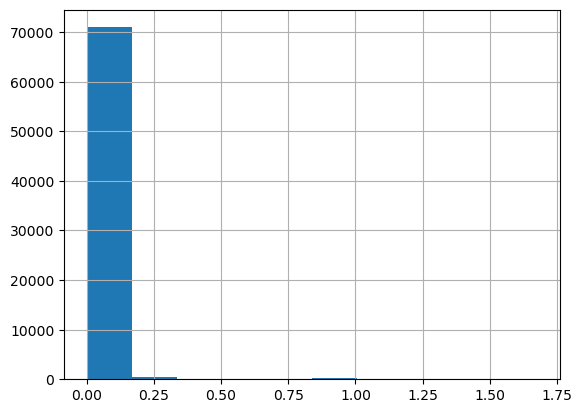

In [ ]:
df_data['dem2_VI_mid_std_200'].

## Single feature analysis

In [130]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

def analyze_feature_correlations(df, column, class_column, percentiles=[10, 20, 30, 40, 50, 60, 70, 80, 90], 
                                min_samples=50, top_n=10):

    # Create binary columns for each class
    unique_classes = df[class_column].unique()
    results = []
    
    for target_class in unique_classes:
        binary_target = (df[class_column] == target_class).astype(int)
        
        for percentile in percentiles:
            threshold = df[column].quantile(percentile/100)
            abs_threshold = abs(df[column]).quantile(percentile/100)
            
            # Test different threshold conditions
            conditions = [
                ('>=', df[column] >= threshold, threshold),
                ('<', df[column] < threshold, threshold),
                ('abs>', abs(df[column]) > abs_threshold, abs_threshold),
                ('abs<', abs(df[column]) < abs_threshold, abs_threshold)
            ]
            
            for condition_name, mask, thresh in conditions:
                if mask.sum() >= min_samples:
                    # Calculate correlation
                    corr = mask.astype(int).corr(binary_target)
                    
                    if not pd.isna(corr):
                        results.append({
                            'feature': column,
                            'condition': condition_name,
                            'threshold': thresh,
                            'percentile': percentile,
                            'target_class': target_class,
                            'correlation': corr,
                            'abs_correlation': abs(corr),
                            'sample_size': mask.sum(),
                            'trigger_rate': mask.mean(),
                            'class_rate_when_triggered': binary_target[mask].mean() if mask.sum() > 0 else 0
                        })
    
    # Convert to DataFrame and sort by absolute correlation
    results_df = pd.DataFrame(results)
    if len(results_df) > 0:
        results_df = results_df.sort_values('abs_correlation', ascending=False)
        
        # Display top results
        print(f"🔍 Feature: {column}")
        print(f"📊 Target classes: {list(unique_classes)}")
        print(f"📈 Top {top_n} correlations:")
        print("="*80)
        
        for i, (_, row) in enumerate(results_df.head(top_n).iterrows(), 1):
            print(f"{i:2d}. {row['feature']} {row['condition']} {row['threshold']:.4f}")
            print(f"    Class: {row['target_class']} | Correlation: {row['correlation']:.4f} | "
                  f"Trigger: {row['trigger_rate']:.1%} | Class rate: {row['class_rate_when_triggered']:.3f}")
    
    return results_df

# Usage examples:

# Analyze a single feature
results = analyze_feature_correlations(
    df=df_data, 
    column='obook_b_price_sparsity_dem2', 
    class_column='multiclass_label',
)


🔍 Feature: obook_b_price_sparsity_dem2
📊 Target classes: [1, 2, 0]
📈 Top 10 correlations:
 1. obook_b_price_sparsity_dem2 >= 0.0900
    Class: 0 | Correlation: 0.0723 | Trigger: 45.0% | Class rate: 0.071
 2. obook_b_price_sparsity_dem2 abs> 0.0800
    Class: 0 | Correlation: 0.0723 | Trigger: 45.0% | Class rate: 0.071
 3. obook_b_price_sparsity_dem2 abs< 0.0900
    Class: 0 | Correlation: -0.0723 | Trigger: 55.0% | Class rate: 0.038
 4. obook_b_price_sparsity_dem2 < 0.0900
    Class: 0 | Correlation: -0.0723 | Trigger: 55.0% | Class rate: 0.038
 5. obook_b_price_sparsity_dem2 abs> 0.0700
    Class: 0 | Correlation: 0.0691 | Trigger: 56.0% | Class rate: 0.067
 6. obook_b_price_sparsity_dem2 abs< 0.0800
    Class: 0 | Correlation: -0.0691 | Trigger: 44.0% | Class rate: 0.035
 7. obook_b_price_sparsity_dem2 < 0.0800
    Class: 0 | Correlation: -0.0691 | Trigger: 44.0% | Class rate: 0.035
 8. obook_b_price_sparsity_dem2 >= 0.0800
    Class: 0 | Correlation: 0.0691 | Trigger: 56.0% | Class 

In [132]:
df_data.columns

Index(['datetime', 'nanotime', 'obook_a_price_dem2', 'obook_b_price_dem2',
       'obook_b_price_sparsity_dem2', 'obook_a_price_sparsity_dem2',
       'obook_ba_volrat_00_dem2', 'obook_ba_volrat_30_dem2',
       'obook_ba_volrat_50_dem2', 'obook_ba_volrat_90_dem2',
       'll_aux_dem1_dem2_fair_price', 'll_aux_dem1_dem2_fair_ret',
       'dem2_VI_mid_std_200', 'dem2_target_class_long_prob_400_VI_mid_std_200',
       'dem2_target_class_short_prob_400_VI_mid_std_200',
       'atr_dem2_candles_5min_lookback_21',
       'atr_dem2_candles_10min_lookback_21', 'atr_1h_21_dem2', 'trd_price',
       'trd_side', 'trd_gap', 'multiclass_label', 'fair_price_gap'],
      dtype='object')

In [196]:
df_data.columns

Index(['datetime', 'nanotime', 'obook_a_price_dem2', 'obook_b_price_dem2',
       'obook_b_price_sparsity_dem2', 'obook_a_price_sparsity_dem2',
       'obook_ba_volrat_00_dem2', 'obook_ba_volrat_30_dem2',
       'obook_ba_volrat_50_dem2', 'obook_ba_volrat_90_dem2',
       'll_aux_dem1_dem2_fair_price', 'll_aux_dem1_dem2_fair_ret',
       'dem2_VI_mid_std_200', 'dem2_target_class_long_prob_400_VI_mid_std_200',
       'dem2_target_class_short_prob_400_VI_mid_std_200',
       'atr_dem2_candles_5min_lookback_21',
       'atr_dem2_candles_10min_lookback_21', 'atr_1h_21_dem2', 'trd_price',
       'trd_side', 'trd_gap', 'multiclass_label', 'fair_price_gap',
       'obook_a_price_sparsity_dem2_rolling_50',
       'obook_a_price_sparsity_dem2_rolling_100',
       'obook_a_price_sparsity_dem2_rolling_200',
       'obook_b_price_sparsity_dem2_rolling_50',
       'obook_b_price_sparsity_dem2_rolling_100',
       'obook_b_price_sparsity_dem2_rolling_200'],
      dtype='object')

In [300]:
# One-liner version
mask = df_data['obook_a_price_sparsity_dem2_rolling_50'] > 0.1
# mask &= df_data['obook_a_price_sparsity_dem2'] > 0.2
# mask &= df_data['obook_ba_volrat_50_dem2'] > 0.4

print('shape', mask.sum())
print('Base\n', df_data['multiclass_label'].value_counts()/df_data.shape[0], '\n*****************')
df_data[mask]['multiclass_label'].value_counts()/df_data[mask].shape[0]



shape 610
Base
 multiclass_label
1    0.874777
2    0.072369
0    0.052854
Name: count, dtype: float64 
*****************


multiclass_label
1    0.847541
2    0.108197
0    0.044262
Name: count, dtype: float64

In [298]:
# Calculate expected loss for filtered data
class_dist = df_data[mask]['multiclass_label'].value_counts(normalize=True)

# Expected loss for predicting LONG (class 2)
loss_long = (class_dist.get(0, 0) * loss_mx[0, 2] + 
             class_dist.get(1, 0) * loss_mx[1, 2] + 
             class_dist.get(2, 0) * loss_mx[2, 2])

# Expected loss for predicting SHORT (class 0)  
loss_short = (class_dist.get(0, 0) * loss_mx[0, 0] + 
              class_dist.get(1, 0) * loss_mx[1, 0] + 
              class_dist.get(2, 0) * loss_mx[2, 0])

print(f"Expected loss for LONG prediction: {loss_long:.6f}")
print(f"Expected loss for SHORT prediction: {loss_short:.6f}")

class_dist = df_data['multiclass_label'].value_counts(normalize=True)
print("Base loss")
# Expected loss for predicting LONG (class 2)
loss_long = (class_dist.get(0, 0) * loss_mx[0, 2] + 
             class_dist.get(1, 0) * loss_mx[1, 2] + 
             class_dist.get(2, 0) * loss_mx[2, 2])

# Expected loss for predicting SHORT (class 0)  
loss_short = (class_dist.get(0, 0) * loss_mx[0, 0] + 
              class_dist.get(1, 0) * loss_mx[1, 0] + 
              class_dist.get(2, 0) * loss_mx[2, 0])

print(f"Expected loss for LONG prediction: {loss_long:.6f}")
print(f"Expected loss for SHORT prediction: {loss_short:.6f}")


Expected loss for LONG prediction: 0.596774
Expected loss for SHORT prediction: 1.806452
Base loss
Expected loss for LONG prediction: 1.033338
Expected loss for SHORT prediction: 1.091885


In [301]:
df_data[mask]

,datetime,nanotime,obook_a_price_dem2,obook_b_price_dem2,obook_b_price_sparsity_dem2,obook_a_price_sparsity_dem2,obook_ba_volrat_00_dem2,obook_ba_volrat_30_dem2,obook_ba_volrat_50_dem2,obook_ba_volrat_90_dem2,...,trd_side,trd_gap,multiclass_label,fair_price_gap,obook_a_price_sparsity_dem2_rolling_50,obook_a_price_sparsity_dem2_rolling_100,obook_a_price_sparsity_dem2_rolling_200,obook_b_price_sparsity_dem2_rolling_50,obook_b_price_sparsity_dem2_rolling_100,obook_b_price_sparsity_dem2_rolling_200
tradeid,,,,,,,,,,,,,,,,,,,,,
Eurex T7/DEBY012026-20250401/254/1,2025-04-01 08:59:17,85384170.0,70.05,70.00,0.27,0.23,0.000000,-0.272727,0.259259,0.179487,...,NaN,0.0,1,NaN,0.1068,0.1219,0.12295,0.1122,0.1210,0.13450
Eurex T7/DEBY012026-20250401/254/1,2025-04-01 08:59:17,85384170.0,70.05,70.00,0.27,0.23,0.000000,-0.272727,0.259259,0.179487,...,NaN,0.0,1,NaN,0.1048,0.1206,0.12240,0.1080,0.1196,0.13360
Eurex T7/DEBY012026-20250401/655/1,2025-04-01 09:28:39,995471378.0,70.09,69.97,0.04,0.23,-0.200000,0.238095,0.040000,-0.161290,...,NaN,0.0,1,NaN,0.1206,0.1111,0.12310,-0.0204,-0.0220,-0.02950
Eurex T7/DEBY012026-20250401/655/1,2025-04-01 09:28:39,995471378.0,70.09,69.97,0.04,0.23,-0.200000,0.238095,0.040000,-0.161290,...,NaN,0.0,1,NaN,0.1184,0.1100,0.12210,-0.0200,-0.0216,-0.02940
Eurex T7/DEBM052025-20250401/658/2,2025-04-01 09:28:40,194384259.0,70.09,69.99,0.04,0.23,-0.500000,0.200000,-0.172414,-0.200000,...,NaN,0.0,1,NaN,0.1162,0.1089,0.12110,-0.0196,-0.0212,-0.02930
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Eurex T7/DEBM052025-20250409/2570/1,2025-04-09 10:28:48,371180106.0,71.64,71.47,0.15,0.28,-0.200000,0.259259,-0.040000,-0.142857,...,NaN,0.0,1,NaN,0.1370,0.1558,0.16975,0.0626,0.0597,0.05965
Eurex T7/DEBM052025-20250409/2571/1,2025-04-09 10:28:49,916794909.0,71.64,71.47,0.15,0.28,-0.200000,0.259259,-0.040000,-0.142857,...,NaN,0.0,1,NaN,0.1346,0.1539,0.16915,0.0612,0.0591,0.05915
Eurex T7/DEBQ072025-20250409/2671/1,2025-04-09 10:32:43,622333324.0,71.64,71.45,0.07,0.20,-0.333333,0.428571,0.037037,-0.034483,...,NaN,0.0,1,NaN,0.1076,0.0693,0.07740,-0.0022,-0.0120,-0.01475


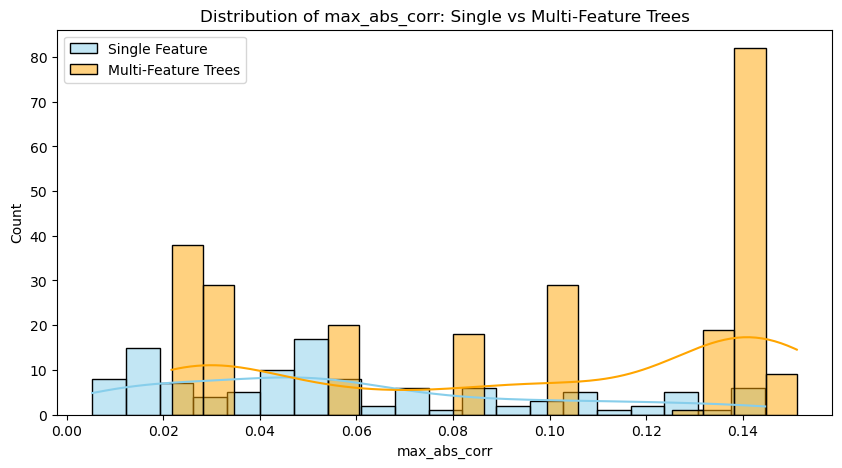

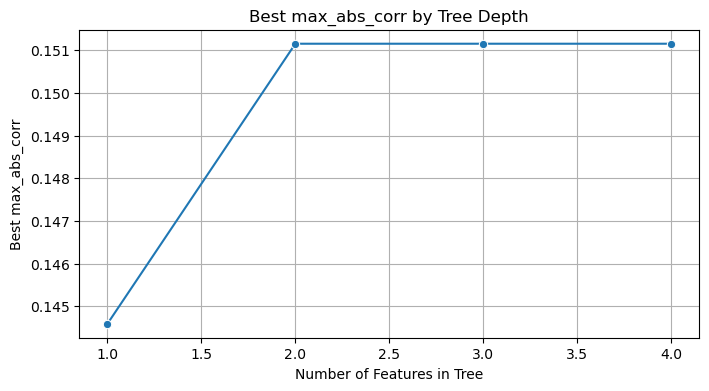

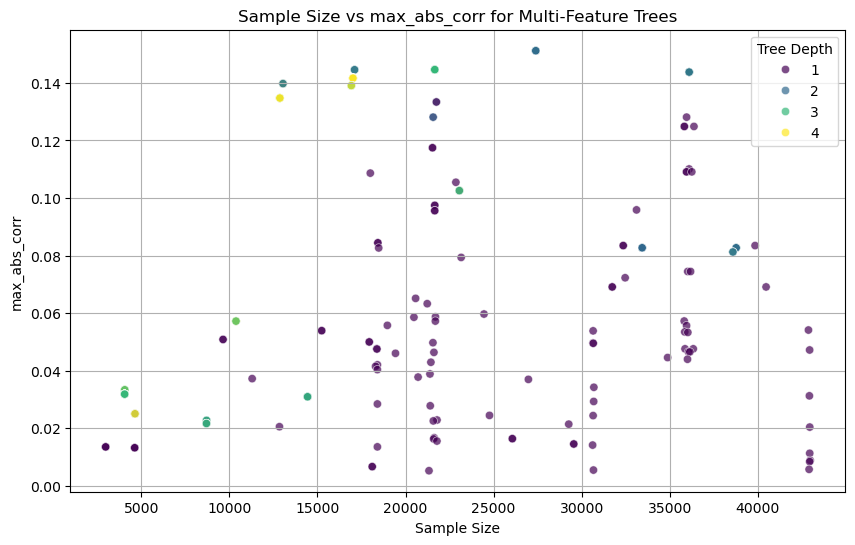

In [123]:
import seaborn as sns

import matplotlib.pyplot as plt

# Plot: Single condition max_abs_corr distribution
single_corrs = multi_condition_trees[multi_condition_trees['num_conditions'] == 1]['max_abs_corr']
multi_corrs = multi_condition_trees[multi_condition_trees['num_conditions'] > 1]['max_abs_corr']

plt.figure(figsize=(10, 5))
sns.histplot(single_corrs, bins=20, color='skyblue', label='Single Feature', kde=True)
sns.histplot(multi_corrs, bins=20, color='orange', label='Multi-Feature Trees', kde=True)
plt.title('Distribution of max_abs_corr: Single vs Multi-Feature Trees')
plt.xlabel('max_abs_corr')
plt.ylabel('Count')
plt.legend()
plt.show()

# Plot: Correlation improvement by tree depth
tree_depths = multi_condition_trees.groupby('num_conditions')['max_abs_corr'].max().reset_index()
plt.figure(figsize=(8, 4))
sns.lineplot(data=tree_depths, x='num_conditions', y='max_abs_corr', marker='o')
plt.title('Best max_abs_corr by Tree Depth')
plt.xlabel('Number of Features in Tree')
plt.ylabel('Best max_abs_corr')
plt.grid(True)
plt.show()

# Plot: All trees - scatter of sample_size vs max_abs_corr, colored by num_conditions
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=multi_condition_trees,
    x='sample_size',
    y='max_abs_corr',
    hue='num_conditions',
    palette='viridis',
    alpha=0.7
)
plt.title('Sample Size vs max_abs_corr for Multi-Feature Trees')
plt.xlabel('Sample Size')
plt.ylabel('max_abs_corr')
plt.legend(title='Tree Depth')
plt.grid(True)
plt.show()